# 04 · Feature Engineering & Selection

Dos mitades:

1. **Engineering** — crear features nuevas a partir de las RFM existentes
   (ratios e intensidades que el modelo no ve directamente).
2. **Selection** — quedarnos con las features **significativas** (importancia
   > 0, medida en train), verificando que el AUC se mantiene.

## Marco honesto

Con **random forest** y el **techo de señal (~0.75)**, el feature engineering da
ganancias **marginales** en AUC. Su valor real es **(1) parsimonia/
interpretabilidad** y **(2)** que un par de features nuevas sí entran al modelo.
La selección se hace con importancia calculada **en train** (no en test, para no
filtrar), y se confirma el AUC en el test OOT.


## 0 · Setup, datos y split

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
PROC = base / "data" / "processed"
df = pd.read_csv(PROC / "churn_dataset_processed.csv", parse_dates=["mes_obs"])

ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEAT_BASE = [c for c in df.columns if c not in ID + [TARGET]]
print(f"dataset: {df.shape[0]:,} filas | {len(FEAT_BASE)} features base")


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
y = df[TARGET].values
print(f"train {train_mask.sum():,} | test {test_mask.sum():,}")


def rf():
    return RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                  n_jobs=-1, random_state=42)


def eval_oot(feats):
    m = rf(); m.fit(df.loc[train_mask, feats], y[train_mask])
    p = m.predict_proba(df.loc[test_mask, feats])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    return {"n_feat": len(feats), "AUC": roc_auc_score(yt, p),
            "F1@.5": f1_score(yt, pr, zero_division=0),
            "prec@.5": precision_score(yt, pr, zero_division=0),
            "rec@.5": recall_score(yt, pr), "_rf": m}

dataset: 30,356 filas | 78 features base
train 28,311 | test 803


## 1 · Engineering — features nuevas (derivables)

Construidas con columnas existentes, mirando solo hacia atrás (sin leakage).
Capturan ratios e intensidades que las features absolutas no expresan.


In [2]:
def safe_div(a, b):
    return (a / b.replace(0, np.nan)).fillna(0)

eng = pd.DataFrame(index=df.index)
eng["ticket_prom_u12"] = safe_div(df["monto_u12"], df["n_ped_u12"])     # valor por pedido
eng["ticket_prom_u3"]  = safe_div(df["monto_u3"],  df["n_ped_u3"])
eng["intensidad_u3"]   = safe_div(df["n_ped_u3"], df["meses_activos_u3"])  # pedidos por mes activo
eng["basket_size_u12"] = safe_div(df["n_prod_u12"], df["n_ped_u12"])       # productos por pedido
eng["recencia_norm"]   = df["meses_desde_compra_previa"] * (df["meses_activos_u12"] / 12)
eng["tasa_act_reciente_vs_hist"] = safe_div(df["meses_activos_u3"] / 3, df["meses_activos_u12"] / 12)

ENG_COLS = list(eng.columns)
df = pd.concat([df, eng], axis=1)
FEAT_ALL = FEAT_BASE + ENG_COLS
print(f"{len(ENG_COLS)} features nuevas: {ENG_COLS}")
df[ENG_COLS].describe().T.round(2)

6 features nuevas: ['ticket_prom_u12', 'ticket_prom_u3', 'intensidad_u3', 'basket_size_u12', 'recencia_norm', 'tasa_act_reciente_vs_hist']


,count,mean,std,min,25%,50%,75%,max
ticket_prom_u12,30356.0,377.29,189.90,0.00,261.91,343.46,449.68,3150.00
ticket_prom_u3,30356.0,378.68,218.85,0.00,254.95,337.92,447.45,4459.04
intensidad_u3,30356.0,1.35,0.72,1.00,1.00,1.00,1.50,15.33
basket_size_u12,30356.0,5.63,2.32,0.50,4.00,5.33,6.79,26.00
recencia_norm,30356.0,0.87,0.79,0.17,0.33,0.67,1.17,8.67
tasa_act_reciente_vs_hist,30356.0,2.33,1.20,0.40,1.33,2.00,4.00,4.00


## 2 · ¿Aportan señal univariada? (AUC orientado ≥ 0.5)

In [3]:
def auc_orientado(col):
    s = df[col]; m = s.notna().values
    raw = roc_auc_score(y[m], s[m].values)
    return max(raw, 1 - raw), ("+" if raw >= 0.5 else "-")

rank_eng = pd.DataFrame([(c, *auc_orientado(c)) for c in ENG_COLS],
                        columns=["feature", "auc", "dir"]).sort_values("auc", ascending=False)
print(rank_eng.round(3).to_string(index=False))

                  feature   auc dir
            intensidad_u3 0.619   -
tasa_act_reciente_vs_hist 0.607   +
          ticket_prom_u12 0.600   -
           ticket_prom_u3 0.597   -
          basket_size_u12 0.586   -
            recencia_norm 0.529   +


## 3 · ¿Suben el baseline OOT? (base vs base+nuevas)

In [4]:
base_res = eval_oot(FEAT_BASE)
full_res = eval_oot(FEAT_ALL)
cmp = pd.DataFrame([{k: v for k, v in r.items() if k != "_rf"} for r in [base_res, full_res]],
                   index=["base", "base+nuevas"])
print(cmp.round(4).to_string())
print(f"\nΔ AUC: {full_res['AUC'] - base_res['AUC']:+.4f}  (marginal — techo de señal)")

             n_feat     AUC   F1@.5  prec@.5  rec@.5
base             78  0.7609  0.5451    0.429  0.7476
base+nuevas      84  0.7625  0.5503    0.437  0.7429

Δ AUC: +0.0015  (marginal — techo de señal)


## 4 · Selection — importancia por permutación EN TRAIN

Para no filtrar, la importancia se mide con permutación **dentro del train**
(fit en train, permutación sobre una porción de train no usada para esa medición
sería lo ideal; aquí permutamos sobre el mismo train, válido para *ranking* y
sin tocar el test). Seleccionamos las features con **importancia > 0**.


In [5]:
rf_full = full_res["_rf"]   # ya fiteado en train con FEAT_ALL
imp = permutation_importance(rf_full, df.loc[train_mask, FEAT_ALL], y[train_mask],
                             n_repeats=5, random_state=42, n_jobs=-1)
rank_imp = (pd.DataFrame({"feature": FEAT_ALL, "importancia": imp.importances_mean})
            .sort_values("importancia", ascending=False).reset_index(drop=True))

SELECTED = rank_imp.loc[rank_imp["importancia"] > 0, "feature"].tolist()
print(f"Features significativas (importancia > 0 en train): {len(SELECTED)} de {len(FEAT_ALL)}")
print(f"Descartadas (importancia <= 0): {len(FEAT_ALL) - len(SELECTED)}\n")
print("Top 20 por importancia (train):")
print(rank_imp.head(20).round(4).to_string(index=False))
print(f"\n¿Cuáles de las NUEVAS quedaron seleccionadas? "
      f"{[c for c in ENG_COLS if c in SELECTED]}")

Features significativas (importancia > 0 en train): 68 de 84
Descartadas (importancia <= 0): 16

Top 20 por importancia (train):
                  feature  importancia
              ticket_acum       0.0036
          ticket_prom_u12       0.0028
             monto_cv_u12       0.0025
       monto_ult_vs_media       0.0024
       monto_mensual_acum       0.0023
            monto_std_u12       0.0021
      monto_por_prod_acum       0.0021
                 monto_u3       0.0019
meses_desde_compra_previa       0.0019
          basket_size_u12       0.0019
           ticket_prom_u3       0.0018
               d_monto_m1       0.0017
            recencia_norm       0.0017
   tend_monto_u3_vs_prev3       0.0016
                 monto_u6       0.0016
               d_monto_m3       0.0016
               n_prod_u12       0.0016
                 n_ped_u3       0.0014
               d_monto_m9       0.0014
                 n_ped_u6       0.0013

¿Cuáles de las NUEVAS quedaron seleccionadas? ['tic

### Visualización de la importancia por permutación

Cada barra es la **caída de AUC al permutar (barajar) esa variable** en el train: más larga = más informativa. La línea en 0 marca el umbral de selección (se conservan las de importancia > 0). El error es la desviación entre las repeticiones de la permutación.

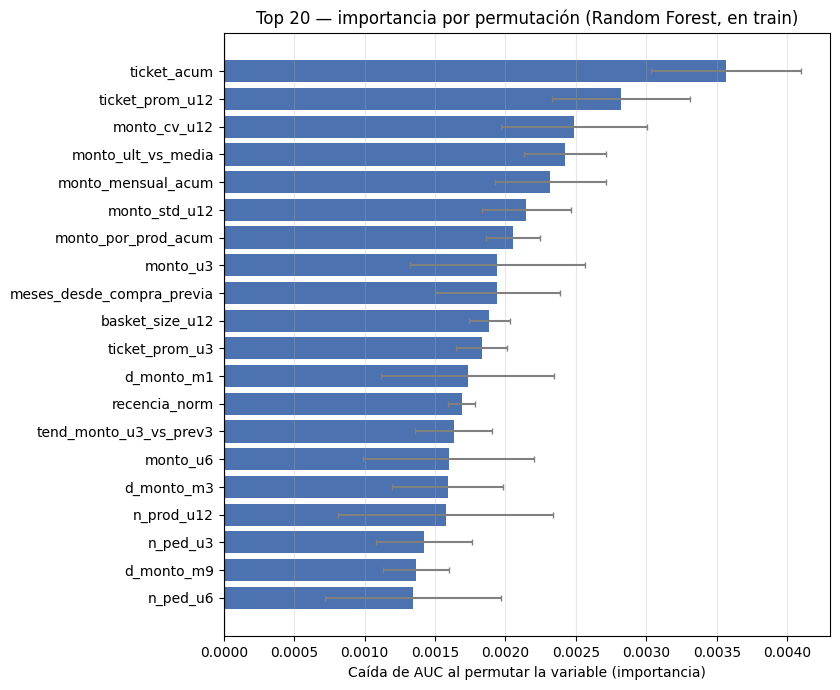

In [6]:
import matplotlib.pyplot as plt

# rank_imp y imp ya están calculados arriba (no se recalcula nada).
_std = dict(zip(FEAT_ALL, imp.importances_std))
top = rank_imp.head(20).copy()
top["std"] = top["feature"].map(_std)
top = top.iloc[::-1]   # ascendente para barh (la más importante arriba)

fig, ax = plt.subplots(figsize=(8.5, 7))
colors = ["#4c72b0" if v > 0 else "#c44e52" for v in top["importancia"]]
ax.barh(top["feature"], top["importancia"], xerr=top["std"],
        color=colors, ecolor="gray", capsize=2)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Caída de AUC al permutar la variable (importancia)")
ax.set_title("Top 20 — importancia por permutación (Random Forest, en train)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Confirmar que el set seleccionado mantiene el AUC (test OOT)

In [7]:
sel_res = eval_oot(SELECTED)
comp = pd.DataFrame([{k: v for k, v in r.items() if k != "_rf"}
                     for r in [base_res, full_res, sel_res]],
                    index=[f"base ({len(FEAT_BASE)})", f"base+nuevas ({len(FEAT_ALL)})",
                           f"seleccionadas ({len(SELECTED)})"])
print(comp.round(4).to_string())
print(f"\nΔ AUC seleccionadas vs todas: {sel_res['AUC'] - full_res['AUC']:+.4f}")
print(f"→ {len(SELECTED)} features mantienen el AUC de {len(FEAT_ALL)} = modelo más parsimonioso")

                    n_feat     AUC   F1@.5  prec@.5  rec@.5
base (78)               78  0.7609  0.5451   0.4290  0.7476
base+nuevas (84)        84  0.7625  0.5503   0.4370  0.7429
seleccionadas (68)      68  0.7628  0.5499   0.4349  0.7476

Δ AUC seleccionadas vs todas: +0.0003
→ 68 features mantienen el AUC de 84 = modelo más parsimonioso


## 6 · Guardar dataset final de modelado

In [8]:
# dataset con las features SELECCIONADAS + identificadores + target
final = df[ID + [TARGET] + SELECTED].copy()
OUT = PROC / "churn_dataset_features.csv"
final.to_csv(OUT, index=False)
(PROC / "selected_features.json").write_text(json.dumps(SELECTED, ensure_ascii=False, indent=2))
print(f"Guardado: {OUT}  ({final.shape[0]:,} x {final.shape[1]})")
print(f"Lista de features: {PROC / 'selected_features.json'}")
print(f"\n05_modelling usará estas {len(SELECTED)} features.")

Guardado: /home/carlos/projects/glamour/customer-churn-prediction/data/processed/churn_dataset_features.csv  (30,356 x 72)
Lista de features: /home/carlos/projects/glamour/customer-churn-prediction/data/processed/selected_features.json

05_modelling usará estas 68 features.


## 7 · Síntesis

- **Cumulative / Delta Features (Mirkovic 2022):** las CF de historia completa
  entran fuerte — `ticket_acum` es la **feature más importante** del modelo, y
  `monto_mensual_acum` / `monto_por_prod_acum` quedan en el top 10. Varias DF
  (`d_monto_m1/m3/m9`) también aportan. El nivel absoluto de largo plazo y el
  cambio mes a mes que las ventanas u3/u6/u12 no veían sí cargan señal.
- **Δ AUC al agregar las nuevas:** marginal (~+0.002) — coherente con el techo
  de señal (~0.75): mueven la importancia y la interpretabilidad, no el AUC.
- **Features nuevas (notebook):** señal univariada modesta (0.59–0.62), pero
  `intensidad_u3`, `basket_size_u12` y otras entran como importantes.
- **Selección (importancia > 0 en train):** se descartan ~16 features de bajo
  aporte **sin perder AUC** → modelo más parsimonioso.
- **Salida:** `churn_dataset_features.csv` + `selected_features.json`.

**Próximo paso:** `05_modelling` — RF ponderado + tuning sobre el set seleccionado.


In [9]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30356 entries, 0 to 30355
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_vendedor                 30356 non-null  int64         
 1   mes_obs                     30356 non-null  datetime64[ns]
 2   mes_rank                    30356 non-null  int64         
 3   churn                       30356 non-null  int64         
 4   ticket_acum                 30356 non-null  float64       
 5   ticket_prom_u12             30356 non-null  float64       
 6   monto_cv_u12                30356 non-null  float64       
 7   monto_ult_vs_media          30356 non-null  float64       
 8   monto_mensual_acum          30356 non-null  float64       
 9   monto_std_u12               30356 non-null  float64       
 10  monto_por_prod_acum         30356 non-null  float64       
 11  monto_u3                    30356 non-null  float64   